# Belief propagation for the Gaussian AR(1) diffusion model — companion notebook

Interactive twin of **`main.pdf`** (this folder). Built from scratch around the
call with J. Garnier-Brun of 5 June 2026, and around nothing else.

**The model.** Clean data: $a_{k+1}=\alpha a_k+\eta_k$,
$\eta_k\sim\mathcal N(0,1-\alpha^2)$, $a_0\sim\mathcal N(0,1)$ — every frame has
variance 1. Corruption at diffusion time $t$:
$x_k=e^{-t}a_k+\xi_k$, $\xi_k\sim\mathcal N(0,D_t)$, $D_t=1-e^{-2t}$.
Target: the joint score $S(x,t)=\nabla_x\log P_t(x)$.

**Plan** (= the sections of the PDF):
1. The exact answer: $S=-\Sigma_t^{-1}x$, and Tweedie's identity
2. The factor graph and the message equations (F0)–(C), run step by step
3. The checkpoint: BP with two-number Gaussian messages $=$ exact score
4. AMP: per-node mean & variance — the score survives, the variance breaks
5. Experiment 1: truncate the matrix vs truncate the message range
6. Experiment 2: AMP vs the exact score, as a function of $t$

*Discipline: every claim is computed in front of you; `bp_gaussian.py` also
has built-in self-checks (run it as a script).*

In [1]:
import numpy as np
np.set_printoptions(precision=6, suppress=True)
from bp_gaussian import (
    channel, clean_covariance, clean_precision, noisy_covariance,
    exact_score, posterior_mean_matrix, score_from_denoiser,
    bp_messages, bp_posterior, bp_score, _evidence,
    banded_score_matrix, local_bp_score, score_matrix_of_local_bp,
    local_mean_matrix, relative_score_error,
    posterior_natural_params, amp_mean, amp_variance, amp_score,
)
print('bp_gaussian.py loaded')

bp_gaussian.py loaded


## 1. The exact answer (the benchmark)

Two facts derived in PDF §3:
* $\Sigma_0[i,j]=\alpha^{|i-j|}$ and $\Sigma_t=e^{-2t}\Sigma_0+D_t I$, so
  $S(x,t)=-\Sigma_t^{-1}x$ — one linear solve. **This is the ground truth.**
* Tweedie: $S_k=(e^{-t}\,\mathbb E[a_k|x]-x_k)/D_t$ — the score is an affine
  function of the Bayes denoiser. So computing the score $=$ computing a
  per-node posterior mean, which is what message passing produces.

Check the two routes agree, and that the clean precision $Q_0$ is tridiagonal
(the Markov property in matrix form, PDF Step 3.5):

In [2]:
K, alpha, t = 8, 0.7, 0.4
rng = np.random.default_rng(1)
x = rng.standard_normal(K)

S_direct = exact_score(x, alpha, t)
m = posterior_mean_matrix(K, alpha, t) @ x         # E[a|x], the denoiser
S_tweedie = score_from_denoiser(m, x, t)
print('max |direct - Tweedie| =', np.max(np.abs(S_direct - S_tweedie)))

Q0 = clean_precision(K, alpha)
print('max |Q0 @ Sigma0 - I|  =',
      np.max(np.abs(Q0 @ clean_covariance(K, alpha) - np.eye(K))))
mask = np.abs(np.subtract.outer(np.arange(K), np.arange(K))) > 1
print('off-tridiagonal of Q0  =', np.max(np.abs(Q0[mask])), '(exactly zero)')

max |direct - Tweedie| = 2.220446049250313e-16
max |Q0 @ Sigma0 - I|  = 4.440892098500626e-16
off-tridiagonal of Q0  = 0.0 (exactly zero)


## 2. The message equations, run step by step

The factor graph (PDF §4) is a line of variables $a_k$ with transition factors
$f_k$ between neighbours, one observation factor $g_k$ hanging off each node,
and the prior capping the left end. The sum–product equations collapse into
two sweeps (PDF §5.3):

| label | operation |
|---|---|
| (F0) | forward starts at the prior $\mathcal N(0,1)$ |
| (F1) | **combine**: absorb the local pseudo-observation (precisions add) |
| (F2) | **propagate**: push through the transition ($m\!\to\!\alpha m$, $v\!\to\!\alpha^2v+\sigma_\eta^2$) |
| (B0) | backward starts flat (nothing right of the end) |
| (B1)/(B2) | same two operations, mirrored |
| (C) | belief: forward $\times$ observation $\times$ backward |

**The trap** (PDF Remark 1): the forward message *arriving* at node $k$ must
NOT contain $x_k$ — the local observation enters once, at combination time.

Reproduce the worked instance of PDF §5.5 ($K=4$, $\alpha=0.6$, $t=0.3$):

In [3]:
K4, a4, t4 = 4, 0.6, 0.3
x4 = np.array([0.9, -0.2, 0.5, -1.1])
mu4, D4 = channel(t4)
print(f'e^-t={mu4:.6f}  D_t={D4:.6f}  pseudo-obs variance={D4/mu4**2:.6f}\n')

mf, vf, mb, vb = bp_messages(x4, a4, t4)
print('k   forward (m,v)            pseudo-obs (m,v)         backward (m,v)')
for k in range(K4):
    me, ve = _evidence(x4[k], t4)
    bw = 'flat' if np.isinf(vb[k]) else f'({mb[k]:+.5f}, {vb[k]:.5f})'
    print(f'{k}   ({mf[k]:+.5f}, {vf[k]:.5f})   ({me:+.5f}, {ve:.5f})   {bw}')

m_post, v_post = bp_posterior(x4, a4, t4)
print('\nposterior means    :', m_post)
print('posterior variances:', v_post, ' (note the reversal symmetry)')

e^-t=0.740818  D_t=0.451188  pseudo-obs variance=0.822119

k   forward (m,v)            pseudo-obs (m,v)         backward (m,v)
0   (+0.00000, 1.00000)   (+1.21487, 0.82212)   (-0.29429, 3.64415)
1   (+0.40004, 0.80243)   (-0.26997, 0.82212)   (+0.24117, 3.67700)
2   (+0.04146, 0.78619)   (+0.67493, 0.82212)   (-2.47474, 4.06144)
3   (+0.21067, 0.78468)   (-1.48484, 0.82212)   flat

posterior means    : [ 0.560859  0.086209  0.096678 -0.617332]
posterior variances: [0.40148  0.365691 0.365691 0.40148 ]  (note the reversal symmetry)


In [4]:
# one forward step by hand, so nothing is hidden (PDF, hand-check paragraph)
lam = 1.0 + mu4*mu4/D4                  # (F1): precisions add (prior + evidence)
v_c = 1.0/lam
m_c = v_c * (0.0/1.0 + (mu4/D4)*x4[0])  # precision-weighted means add
print(f'(F1) combined at node 0 : m={m_c:.6f}  v={v_c:.6f}')
m_next = a4*m_c                          # (F2): through the transition
v_next = a4*a4*v_c + (1 - a4*a4)
print(f'(F2) message into a_1   : m={m_next:.6f}  v={v_next:.6f}')
print(f'code forward at k=1     : m={mf[1]:.6f}  v={vf[1]:.6f}   -> match')

(F1) combined at node 0 : m=0.666736  v=0.451188
(F2) message into a_1   : m=0.400042  v=0.802428
code forward at k=1     : m=0.400042  v=0.802428   -> match


## 3. The checkpoint

The call's proposed test: *"can we actually do this with a message-passing
algorithm ... and see if we recover what we had?"* Sweep
$K\in\{2,3,6,12\}$, $\alpha\in\{0.3,0.7,0.9,-0.5\}$, $t\in\{0.05,0.4,1.2,3\}$:

In [5]:
worst = 0.0
for Kk in (2, 3, 6, 12):
    for aa in (0.3, 0.7, 0.9, -0.5):
        for tt in (0.05, 0.4, 1.2, 3.0):
            xx = np.random.default_rng(Kk).standard_normal(Kk)
            worst = max(worst, np.max(np.abs(
                bp_score(xx, aa, tt) - exact_score(xx, aa, tt))))
print('max |S_BP - S_exact| over 64 configurations =', worst)
print('\nCHECKPOINT PASSES: two-number Gaussian messages run BP without loss.')
print('Why exactly (not approximately): every update is a product of Gaussians')
print('or a linear-Gaussian integral -- the family is closed. No CLT anywhere.')

max |S_BP - S_exact| over 64 configurations = 8.118505867571457e-15

CHECKPOINT PASSES: two-number Gaussian messages run BP without loss.
Why exactly (not approximately): every update is a product of Gaussians
or a linear-Gaussian integral -- the family is closed. No CLT anywhere.


## 4. AMP: per-node mean and variance

The call's reduction: keep one $(m_i, V_i)$ per **node** (not per edge) and
update self-consistently against the aggregate of the neighbours
(PDF §6, eqs. (A1)–(A2)):

$$m_i \leftarrow \frac{h_i-\sum_{j\ne i}J_{ij}m_j}{J_{ii}},\qquad
V_i \leftarrow \frac{1}{J_{ii}-\sum_{j\ne i}J_{ij}^2V_j}.$$

* The mean fixed point satisfies $Jm=h$ **exactly** → AMP's score = exact
  score, at every $t$, no matter the variances.
* The variance closure uses each neighbour's *full* variance (no cavity
  exclusion) — the step justified by a CLT over many neighbours. Here there
  are two. *"The central limit theorem on two data points is usually not
  right."* Watch it fail:

In [6]:
K2, a2 = 12, 0.8
x2 = np.random.default_rng(11).standard_normal(K2)
print(f'chain K={K2}, alpha={a2}:\n')
for tt in (0.05, 0.2, 0.5, 1.0):
    J, h = posterior_natural_params(x2, a2, tt)
    m_amp, _ = amp_mean(J, h)
    Jinv = np.linalg.inv(J)
    V, ok = amp_variance(J)
    vtxt = (f'variance error = {np.max(np.abs(V - np.diag(Jinv))):.2e}' if ok
            else 'variance: NO positive fixed point (breakdown)')
    print(f'  t={tt:<5} score/mean error = '
          f'{np.max(np.abs(m_amp - Jinv @ h)):.1e}   {vtxt}')
print('\nThe factor-2 in one line: BP cavity solves  l = Jd - b^2/l '
      '(discriminant Jd^2-4b^2, always >0);')
print('AMP solves V = 1/(Jd - 2 b^2 V) (discriminant Jd^2-8b^2: fails at '
      'strong coupling / larger t).')

chain K=12, alpha=0.8:

  t=0.05  score/mean error = 1.8e-13   variance error = 1.30e-04
  t=0.2   score/mean error = 4.7e-13   variance error = 3.48e-02
  t=0.5   score/mean error = 1.2e-12   variance: NO positive fixed point (breakdown)
  t=1.0   score/mean error = 2.6e-12   variance: NO positive fixed point (breakdown)

The factor-2 in one line: BP cavity solves  l = Jd - b^2/l (discriminant Jd^2-4b^2, always >0);
AMP solves V = 1/(Jd - 2 b^2 V) (discriminant Jd^2-8b^2: fails at strong coupling / larger t).


## 5. Experiment 1 — how bad is locality?

Two ways to force locality (PDF §7), judged by the **deterministic** relative
RMS error over $x\sim P_t$ (every estimator is linear in $x$, so the error is
a trace — no sampling):

* **1a — truncate the matrix**: keep $Q_t$ entries with $|i-j|\le b$
  ($b=1$: the tridiagonal truncation proposed in the call).
* **1b — truncate the inference**: messages travel at most $r$ hops
  (*"cut the iteration ... local approximations every time"*).

relative RMS score error (K=40, alpha=0.8):

  t      banded b=1   range r=1    banded b=4   range r=4
  0.05   0.2097       0.1228       0.0008       0.0005
  0.3    0.3015       0.2352       0.0277       0.0228
  1.0    0.1346       0.1301       0.0442       0.0429
  3.0    0.0035       0.0035       0.0017       0.0017


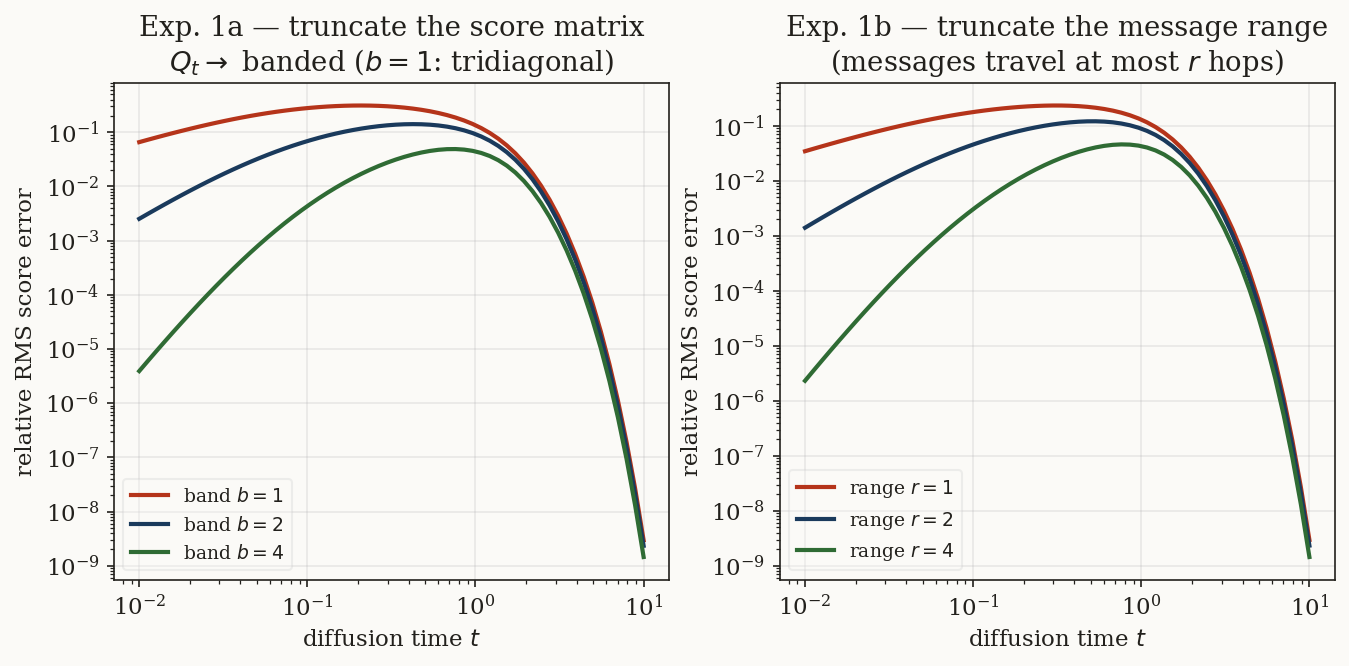

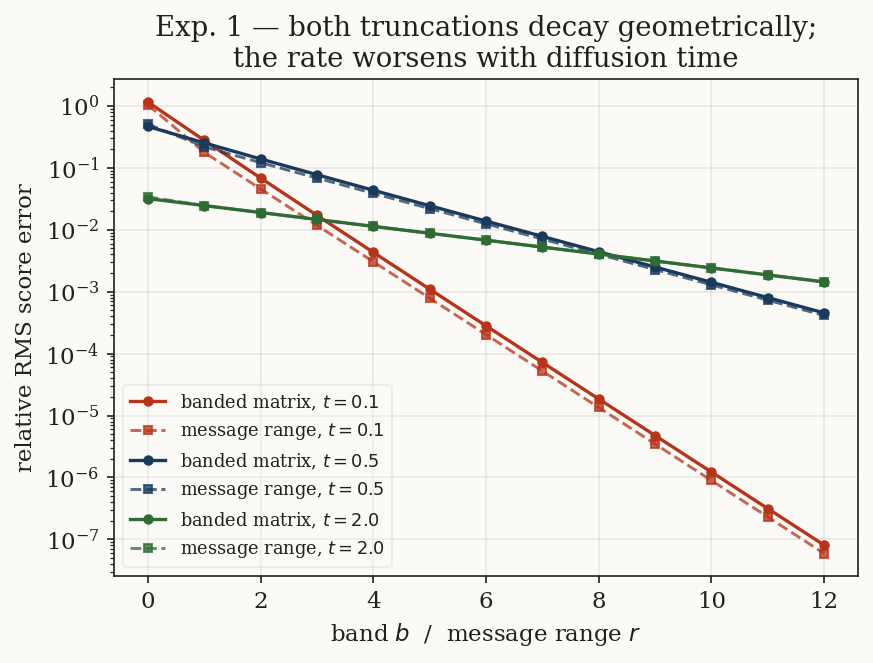

In [7]:
K1, a1 = 40, 0.8
print('relative RMS score error (K=40, alpha=0.8):\n')
print('  t      banded b=1   range r=1    banded b=4   range r=4')
for tt in (0.05, 0.3, 1.0, 3.0):
    eb1 = relative_score_error(banded_score_matrix(K1, a1, tt, 1), K1, a1, tt)
    er1 = relative_score_error(score_matrix_of_local_bp(K1, a1, tt, 1), K1, a1, tt)
    eb4 = relative_score_error(banded_score_matrix(K1, a1, tt, 4), K1, a1, tt)
    er4 = relative_score_error(score_matrix_of_local_bp(K1, a1, tt, 4), K1, a1, tt)
    print(f'  {tt:<5}  {eb1:.4f}       {er1:.4f}       {eb4:.4f}       {er4:.4f}')
from IPython.display import Image, display
display(Image(filename='figures/exp1_truncation.png'))
display(Image(filename='figures/exp1_vs_radius.png'))

**Read-out.** (i) The price of locality peaks at *intermediate* $t$
(up to ~30% for tridiagonal) and is tiny at both ends — the matrix starts
tridiagonal and ends diagonal, exactly the lifecycle discussed in the call.
(ii) Truncating the *inference* beats truncating the *matrix* at small $t$
(12% vs 21% at $t=0.05$): windowed inference solves a correctly-normalised
problem, while zeroing entries of an inverse mis-states the diagonal.
(iii) Architecture reading: a local (CNN/patch-like) score is near-optimal at
small and large $t$ and pays a quantified, bounded price in the middle.

## 6. Experiment 2 — AMP against the exact score

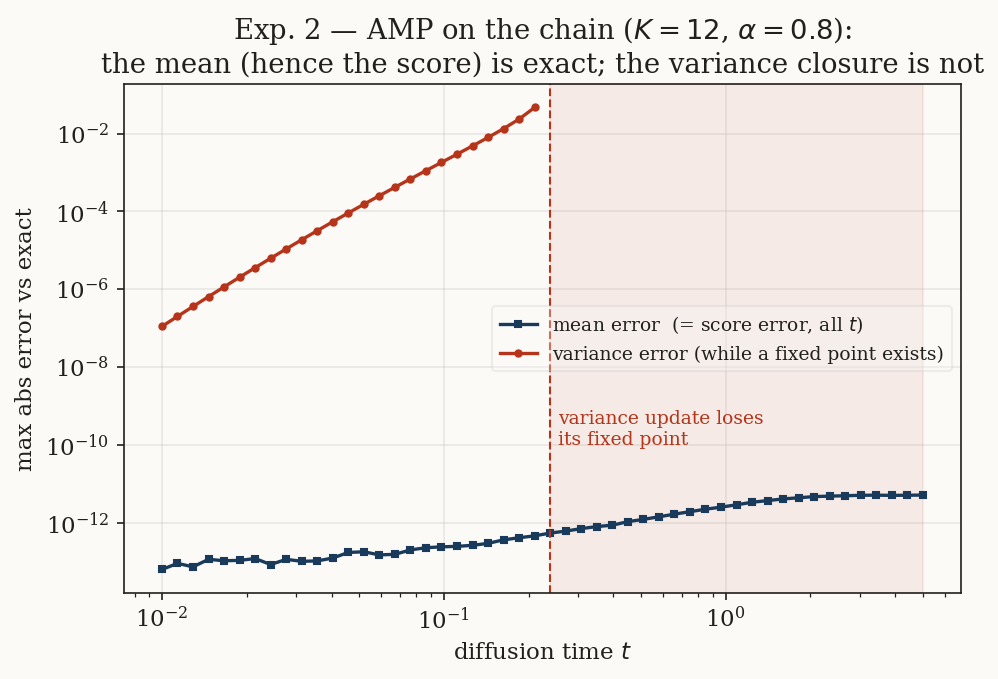

Verdict: the conjectured checkpoint holds exactly for the score (both BP
and AMP); the CLT-on-two-points objection is also right, and its target
is the per-node VARIANCE closure: accurate at small t, degraded by t~0.2,
nonexistent past t~0.23 (alpha=0.8). Score: safe. Uncertainties: use BP.


In [8]:
display(Image(filename='figures/exp2_amp.png'))
print('Verdict: the conjectured checkpoint holds exactly for the score (both BP')
print('and AMP); the CLT-on-two-points objection is also right, and its target')
print('is the per-node VARIANCE closure: accurate at small t, degraded by t~0.2,')
print('nonexistent past t~0.23 (alpha=0.8). Score: safe. Uncertainties: use BP.')

## Summary

1. **Continuous messages are not an obstruction here**: every sum–product
   update maps Gaussians to Gaussians exactly (two numbers per message,
   normalisation never tracked). Gaussian BP *is* BP on this model.
2. **Checkpoint passed**: BP score $=$ exact score to $10^{-14}$, in $O(K)$.
3. **Joint vs marginal Gaussianity**: per-node Gaussian messages do not imply
   a Gaussian joint in general; here the joint posterior is Gaussian because
   its log-density is quadratic — the implication runs model → messages.
4. **AMP**: same score at every $t$ (the mean fixed point is $Jm=h$,
   closure-independent); variance accurate only at small $t$, no fixed point
   beyond a threshold — the "CLT on two points", located precisely.
5. **Locality**: worst case ~30% RMS at intermediate $t$ for strictly local
   estimators; geometric improvement with range; truncated inference ≥
   truncated matrix.

Next steps (from the call): the discrete-data route (transition matrix, exact
discrete BP), non-Gaussian innovations (where Gaussian BP becomes a real
approximation), and a $t$-adaptive receptive field for restrained score
architectures.